# set up

In [4]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [17]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [6]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [7]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Fit six areas with 14 conditions

## Decide couping filter hyperparameters

In [48]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
self_effect = False
tau = 15
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}


for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    filter_list = model_stationary.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        stationary_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
    filter_list = model_running.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
#         if i==j:
#             continue
        running_filter[i,j] = filter_list[k]
        k += 1
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
baseline_aic = 297896.09621198074
print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [03:39, 36.61s/it]

AIC improvement of the model is: 31126.113254273194


Text(0.5, 1.0, 'Fitted with $f_{rf}(\\Lambda)$ model; LM; Resting; trial 85')

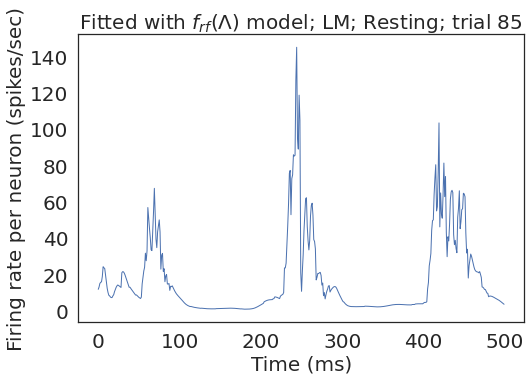

In [49]:
## fontsize = 20
plt.subplots(figsize=(8,5.3))

plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85])/10.625*1e3, linewidth=1)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("Time (ms)", fontsize=fontsize)
plt.ylabel("Firing rate per neuron (spikes/sec)", fontsize=fontsize)
plt.title("Fitted with $f_{rf}(\Lambda)$ model; LM; Resting; trial 85", fontdict = {'fontsize' : 20})

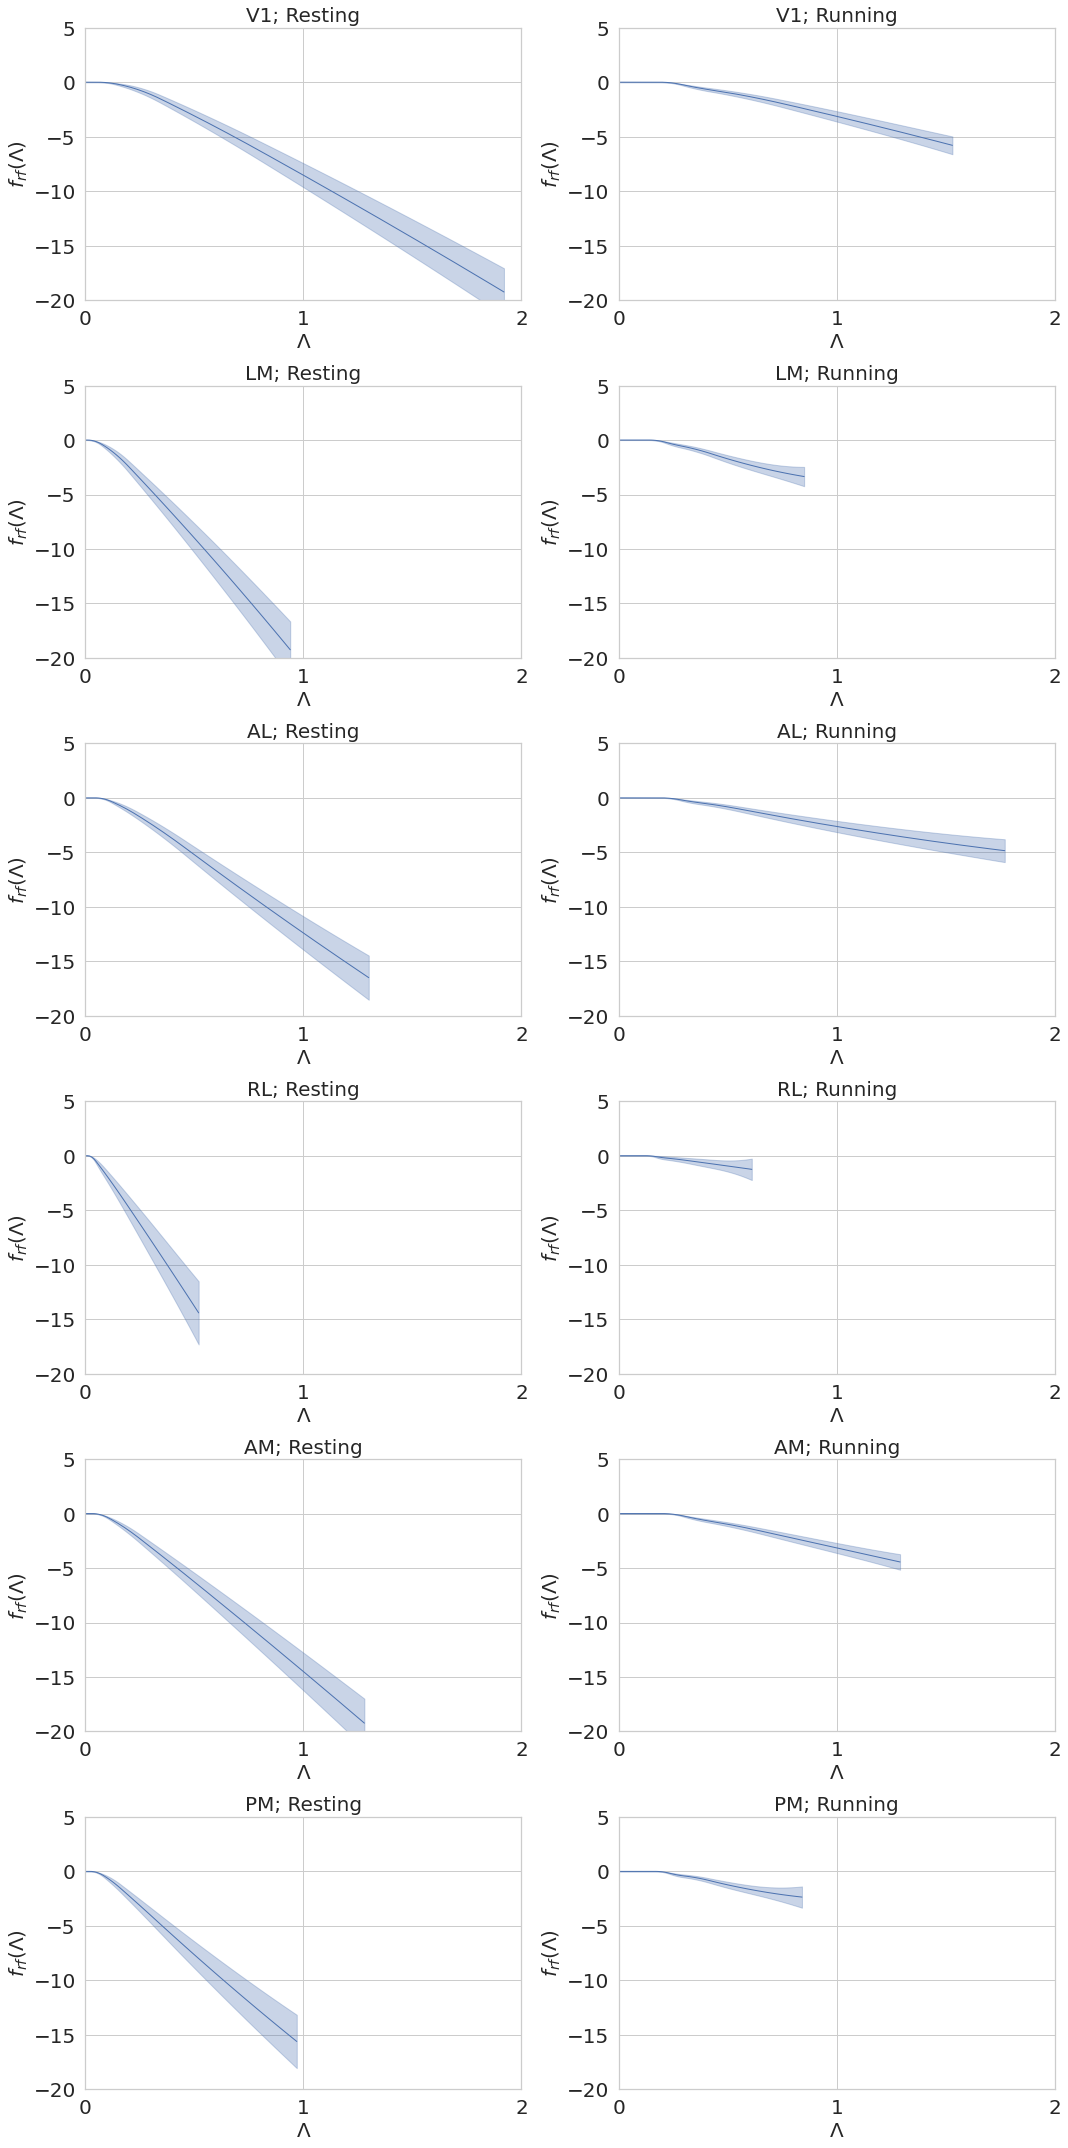

In [21]:
sns.set_style('whitegrid')
fontsize = 20
plt.subplots(figsize=(15,30))
transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}

model_list = stationary_model_list + running_model_list
for ii in range(6):
    i = transfer_ij[ii]
    for j in range(7,8):
        plt.subplot(6,2, 2*ii+j-6)
        model = model_list[i]
        utils.plot_ci(model.get_filter(ci=True)[j], center=True)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.xlabel('$\Lambda$', fontsize=fontsize)
        plt.ylabel('$f_{rf}(\Lambda)$', fontsize=fontsize)
        plt.ylim([-20, 5])
        plt.xlim([0, 200])
        plt.xticks([0, 100, 200], [0, 1, 2])
        plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Resting", fontdict = {'fontsize' : 20})
    for j in range(7,8):
        plt.subplot(6,2, 2*ii+j-5)
        model = model_list[i+6]
        utils.plot_ci(model.get_filter(ci=True)[j], center=True)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.xlabel('$\Lambda$', fontsize=fontsize)
        plt.ylabel('$f_{rf}(\Lambda)$', fontsize=fontsize)
        plt.ylim([-20, 5])
        plt.xlim([0, 200])
        plt.xticks([0, 100, 200], [0, 1, 2])
        plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Running", fontdict = {'fontsize' : 20})
plt.tight_layout()
sns.set_style('white')

After many tries, the best hyperparameters for coupling filter is 
peaks_max=50, num=6, nonlinear=0.3

## Fit

In [56]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
self_effect = False
tau = 15
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        running_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(ci=True)
    for j in range(len(model.basis_list)):
        running_output[i,j-1] = output_list[j]
    
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        stationary_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(ci=True)
    for j in range(len(model.basis_list)):
        stationary_output[i,j-1] = output_list[j]
    
    # for effect filter
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        ROI_filter[filter_index], statistics_filter[filter_index] = GLM.get_excursion_statistic(function1, function2)
    
    # for effect output
    filter_index = i,-1
    function1 = np.exp( running_output[filter_index][0] )
    function2 = np.exp( stationary_output[filter_index][0] )
    ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_output[filter_index][0]
        function2 = stationary_output[filter_index][0]
        ROI_output[filter_index], statistics_output[filter_index] = GLM.get_excursion_statistic(function1, function2)

aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
baseline_aic = 297896.09621198074
print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")

6it [03:38, 36.46s/it]

AIC improvement of the model is: 31126.113254273194


In [58]:
fix_peak_time = []
for i_probe in range(6):
    fix_peak_time_single = np.zeros((V1.ntrial, 4))
    i_stationary = 0
    i_running = 0
    for itrial in range(V1.ntrial):
        if stationary_model_list[0].select_trials[itrial] == True:
            fix_peak_time_single[itrial, 1] = stationary_model_list[i_probe].shifts[i_stationary,1]
            fix_peak_time_single[itrial, 3] = stationary_model_list[i_probe].shifts[i_stationary,3]
            fix_peak_time_single[itrial, 0] = stationary_model_list[i_probe].shifts[i_stationary,0]
            fix_peak_time_single[itrial, 2] = stationary_model_list[i_probe].shifts[i_stationary,2]
            i_stationary += 1
        else:
            fix_peak_time_single[itrial, 1] = running_model_list[i_probe].shifts[i_running,1]
            fix_peak_time_single[itrial, 3] = running_model_list[i_probe].shifts[i_running,3]
            fix_peak_time_single[itrial, 0] = running_model_list[i_probe].shifts[i_running,0]
            fix_peak_time_single[itrial, 2] = running_model_list[i_probe].shifts[i_running,2]
            i_running += 1
    fix_peak_time.append(fix_peak_time_single)

## Compare fixing peak times 

In [ ]:
# WITH fixed peak times
from GLM import get_statistics_null_mp
statistics_null_filter_new, statistics_null_output_new = get_statistics_null_mp(100, V1, membership, condition_ids, probe_list, 
                                         num_basis_baseline, coupling_filter_params, fix_peak_time=fix_peak_time)

Starting multiprocessing on linux. 
Cores=5. 
Batch size=5


 65%|██████████████████████▊            | 65/100 [11:01<02:52,  4.93s/it]

In [ ]:
# WITHOUT fixed peak times
from GLM import get_statistics_null_mp
statistics_null_filter_new, statistics_null_output_new = get_statistics_null_mp(100, V1, membership, condition_ids, probe_list, 
                                         num_basis_baseline, coupling_filter_params, fix_peak_time=fix_peak_time)

Starting multiprocessing on linux. 
Cores=5. 
Batch size=5


0it [00:00, ?it/s]                               | 0/100 [00:00<?, ?it/s]

## Random shuffle (Excursion test)

In [60]:
from GLM import get_statistics_null_mp
statistics_null_filter_new, statistics_null_output_new = get_statistics_null_mp(100, V1, membership, condition_ids, probe_list, 
                                         num_basis_baseline, coupling_filter_params, fix_peak_time=fix_peak_time)

Starting multiprocessing on linux. 
Cores=5. 
Batch size=5


100%|██████████████████████████████████| 100/100 [07:32<00:00,  4.52s/it]


In [202]:
# Initialize
statistics_null_filter = statistics_null_filter_new
statistics_null_output = statistics_null_output_new

In [119]:
# Load
with open('statistics_null_filter.pickle', 'rb') as handle:
    statistics_null_filter = pickle.load(handle)
with open('statistics_null_output.pickle', 'rb') as handle:
    statistics_null_output = pickle.load(handle)

# with open('statistics_null_filter_nowarping.pickle', 'rb') as handle:
#     statistics_null_filter = pickle.load(handle)
# with open('statistics_null_output_nowarping.pickle', 'rb') as handle:
#     statistics_null_output = pickle.load(handle)


In [192]:
# Merge new generated samples with the old ones
statistics_null_filter = GLM.merge_dict(statistics_null_filter, statistics_null_filter_new)
statistics_null_output = GLM.merge_dict(statistics_null_output, statistics_null_output_new)

In [120]:
# Save statistics_null_filter and statistics_null_output
with open('statistics_null_filter.pickle', 'wb') as handle:
    pickle.dump(statistics_null_filter, handle)
with open('statistics_null_output.pickle', 'wb') as handle:
    pickle.dump(statistics_null_output, handle)

# with open('statistics_null_filter_nowarping.pickle', 'wb') as handle:
#     pickle.dump(statistics_null_filter, handle)
# with open('statistics_null_output_nowarping.pickle', 'wb') as handle:
#     pickle.dump(statistics_null_output, handle)


In [203]:
np.sum( statistics_null_filter[0,5] > statistics_filter[0,5] ), len( statistics_null_filter[0,5] )

(0, 5000)

In [204]:
np.sum( statistics_null_filter[3,2] > statistics_filter[3,2] ), len( statistics_null_filter[0,5] )

(0, 5000)

In [ ]:
np.sum( statistics_null_filter[3,2] > statistics_filter[3,2] ), len( statistics_null_filter[0,5] )

# Filters and inference on filters

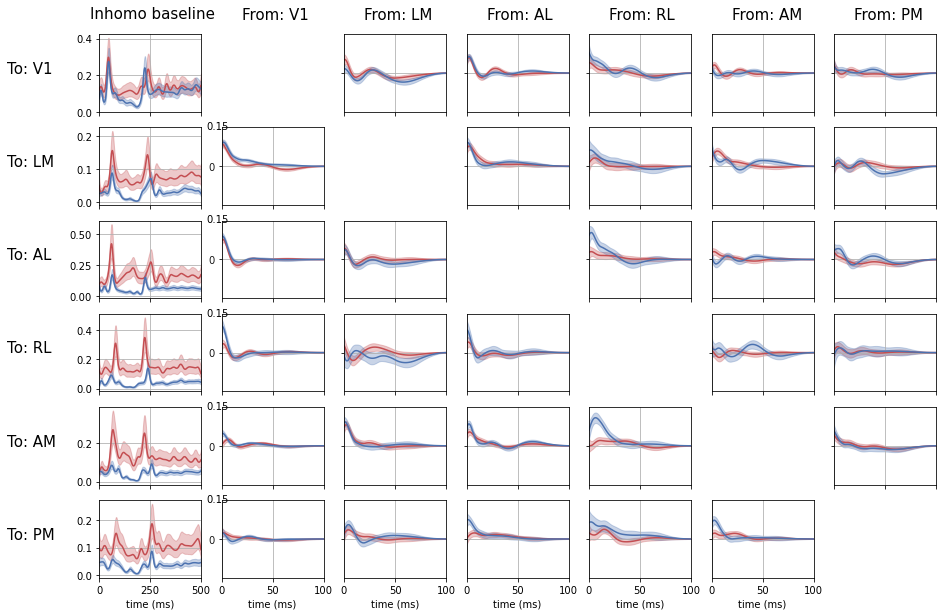

In [117]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False)

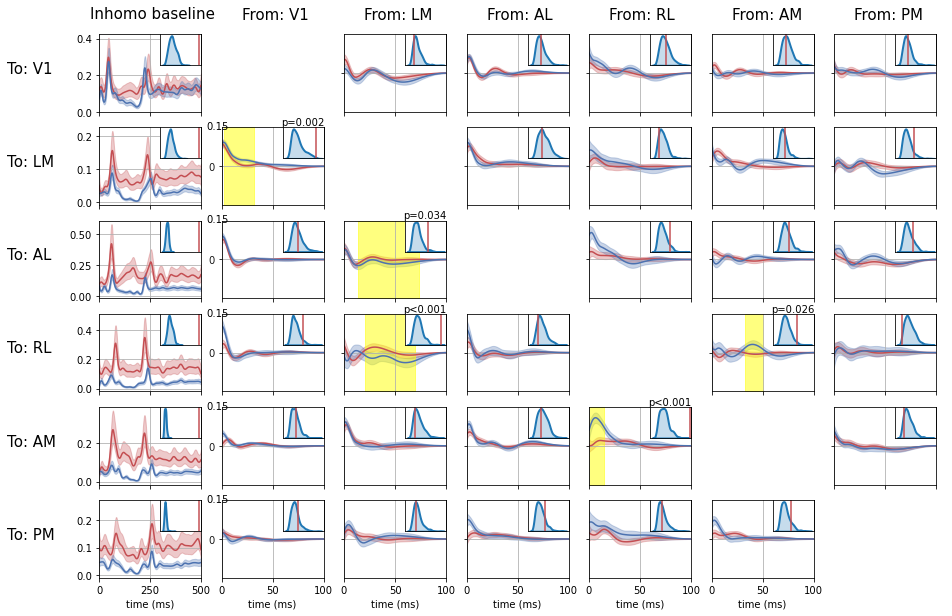

In [121]:
GLM.plot_filter_with_excursion(V1, stationary_filter, running_filter, 
                                statistics_filter=statistics_filter, 
                                statistics_null_filter=statistics_null_filter, 
                                ROI_filter=ROI_filter,
#                                inference=False
                              )

# Illustration of excursion test

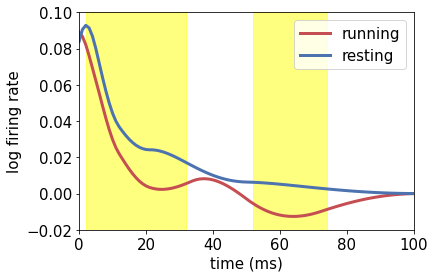

In [31]:
i, j = 1,0
filter_amp = 0.1
# sns.set_theme()
sns.reset_orig()
i_plot = transfer_ij[i]
j_plot = transfer_ij[j]
filter_length = 100
fontsize = 15

filter_index = i_plot,j_plot
#         print(filter_index)
y, ci = running_filter[filter_index]
x = np.arange(y.shape[0])

fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
if j == -1:
    plt.plot(x, np.exp(y),label='running', color='r', linewidth=3)
#     plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
else:
    # Correct for different number of neurons in different areas
    plt.plot(x, y,label='running', color='r', linewidth=3)
#     plt.fill_between(x, (y-2*ci), (y+2*ci), color='r', alpha=.3)

y, ci = stationary_filter[filter_index]
x = np.arange(y.shape[0])
if j == -1:
    plt.plot(x, np.exp(y),label='stationary', color='b',linewidth=3)
#     plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
    plt.xticks([0, trial_length/2, trial_length])
    plt.xlim([0, trial_length])

else:
    plt.plot(x, y,label='resting', color='b', linewidth=3)
#     plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
    plt.ylim([-filter_amp/5, filter_amp])
#     plt.yticks(color='w')
#     plt.xticks([0, filter_length/2, filter_length])
    plt.xlim([0, filter_length])


plt.legend(fontsize=fontsize)
for temp in ROI_filter[filter_index]:
    x = np.array([temp.min(), temp.max()])
    plt.fill_between(x, np.array([-filter_amp,-filter_amp]), np.array([filter_amp,filter_amp]), \
                     color='yellow', alpha=.5)
    plt.xlabel('time (ms)', fontsize=fontsize)
    plt.ylabel('log firing rate', fontsize=fontsize)

In [66]:
ROI_filter[filter_index]

[array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]),
 array([52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
        69, 70, 71, 72, 73, 74])]

# Output and inference on output

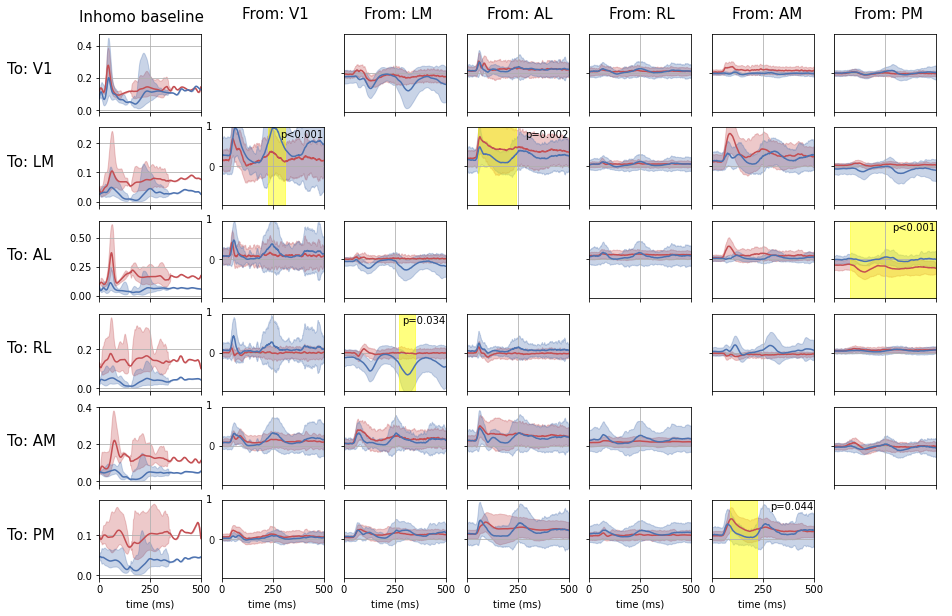

In [129]:
GLM.plot_output_with_excursion(V1, stationary_output, running_output, 
                                statistics_output=statistics_output, 
                                statistics_null_output=statistics_null_output, 
                                ROI_output=ROI_output, 
#                               inference=False
                              )

# Plot all effect's output in an example trial

In [50]:
stationary_model_list[3].basis_name

['time_warping_inhomogeneous_baseline',
 'coupling from AM',
 'coupling from PM',
 'coupling from V1',
 'coupling from LM',
 'coupling from AL',
 'coupling from RL',
 'interaction from V1',
 'trial_coef']

In [51]:
to_look_at = 3
import copy
outputs = [stationary_model_list[to_look_at].get_filter_output(ci=False)[i] for i in range(9)]
outputs[to_look_at+1] += outputs[7]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 8):
    total_output += outputs[i]

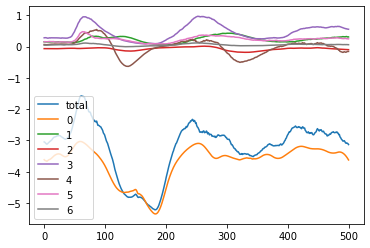

In [52]:
plt.plot(total_output, label='total')
for i, output in enumerate(outputs[:7]):
    plt.plot( output ,label=str(i))
plt.legend()

In [89]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(9)]
outputs[to_look_at+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]


In [92]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(10)]
outputs[to_look_at+1] += outputs[7] + outputs[8]
outputs[0] += outputs[9]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]


Text(0.5, 0, 'time (ms)')

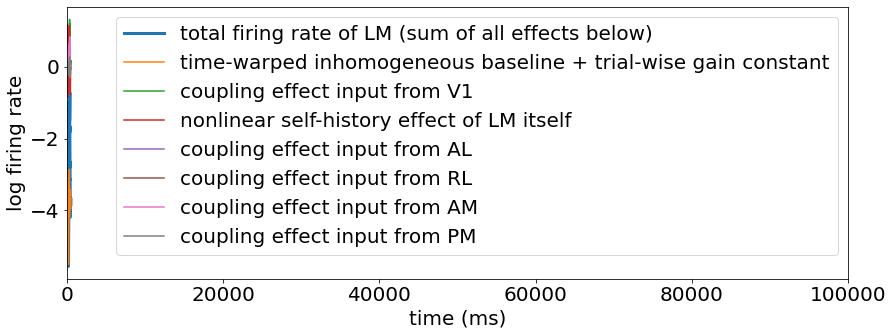

In [93]:
sns.reset_orig()
trial = 1
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(14,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.legend(['total firing rate of LM (sum of all effects below)', 
            'time-warped inhomogeneous baseline + trial-wise gain constant', 
            'coupling effect input from V1', 
            'nonlinear self-history effect of LM itself', 
            'coupling effect input from AL',
            'coupling effect input from RL',
            'coupling effect input from AM',
            'coupling effect input from PM'], fontsize=fontsize)
plt.xlim([-30, 100000])
plt.ylabel('log firing rate', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

Text(0.5, 0, 'time (ms)')

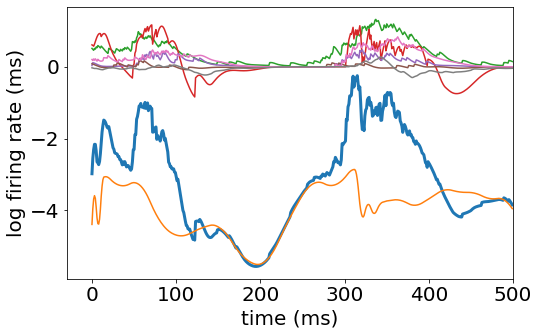

In [98]:
sns.reset_orig()
trial = 1
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

# Simulation

## Use lambda varying post-spike filters to simulate

Use stationary model list and running model list to do simulation

In [8]:
# Fit
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)


6it [04:01, 40.22s/it]


In [19]:
###################
nepoch = 10
model_list = stationary_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd_stationary = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd_stationary = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
peaks_rcd_stationary = np.zeros((2, nepoch*model_list[0].ntrial, len(model_list)))

for iepoch in range(nepoch):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_mat = np.zeros((max_histories_refractory, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

                elif effect_type in ['interaction']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories_refractory:
                        refractory_mat_old = refractory_mat
                        refractory_mat = np.zeros((nhistories, nneuron, nneuron))
                        refractory_mat[-max_histories_refractory:, :, :] = refractory_mat_old
                        max_histories_refractory = nhistories
                    refractory_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect]) 

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (refractory_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory *= recent_spike_sum/tau
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd_stationary[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd_stationary[:, iepoch*model_list[0].ntrial + itrial, :] = spikes
        for ineuron in range(nneuron):
            peaks_rcd_stationary[0, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[:150, ineuron])[:, np.newaxis], std=5))
            peaks_rcd_stationary[1, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[150:, ineuron])[:, np.newaxis], std=5))

In [20]:
###################
nepoch = 10
model_list = running_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd_running = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd_running = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
peaks_rcd_running = np.zeros((2, nepoch*model_list[0].ntrial, len(model_list)))

for iepoch in range(nepoch):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_mat = np.zeros((max_histories_refractory, nneuron, nneuron))
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

                elif effect_type in ['interaction']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories_refractory:
                        refractory_mat_old = refractory_mat
                        refractory_mat = np.zeros((nhistories, nneuron, nneuron))
                        refractory_mat[-max_histories_refractory:, :, :] = refractory_mat_old
                        max_histories_refractory = nhistories
                    refractory_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect]) 

        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (refractory_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory *= recent_spike_sum/tau
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd_running[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd_running[:, iepoch*model_list[0].ntrial + itrial, :] = spikes
        for ineuron in range(nneuron):
            peaks_rcd_running[0, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[:150, ineuron])[:, np.newaxis], std=5))
            peaks_rcd_running[1, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[150:, ineuron])[:, np.newaxis], std=5))

### PSTH compare

#### Experimental PSTH

Text(0.5, 1.0, 'Experimental average firing rate across trials (resting condition)')

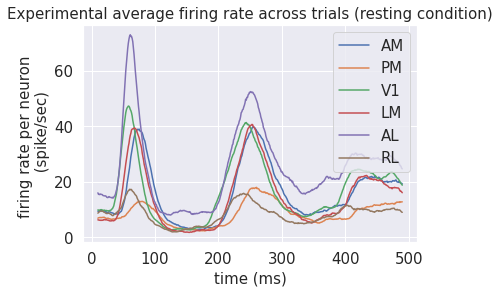

In [16]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']

fontsize = 15
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(stationary_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Experimental average firing rate across trials (resting condition)', fontsize=fontsize)

Text(0.5, 1.0, 'Experimental average firing rate across trials (running condition)')

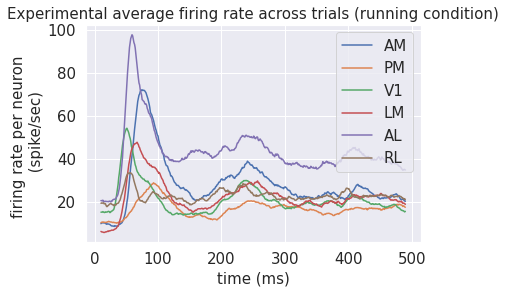

In [17]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(running_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Experimental average firing rate across trials (running condition)', fontsize=fontsize)

#### Simulated PSTH

Text(0.5, 1.0, 'Simulated average firing rate across trials (resting condition)')

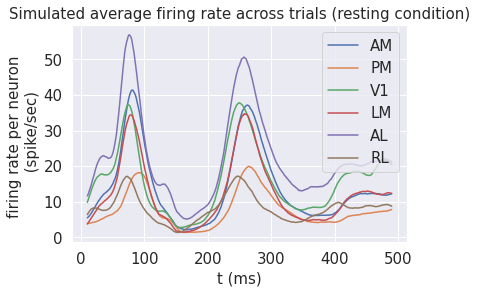

In [21]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd_stationary[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('t (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Simulated average firing rate across trials (resting condition)', fontsize=fontsize)

Text(0.5, 1.0, 'Simulated average firing rate across trials (running condition)')

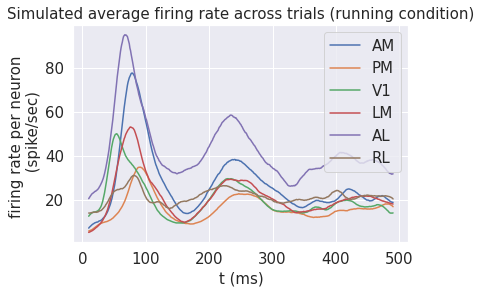

In [22]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd_running[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('t (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Simulated average firing rate across trials (running condition)', fontsize=fontsize)

### Single trial plot

Text(0.5, 1.0, 'Stationary condition')

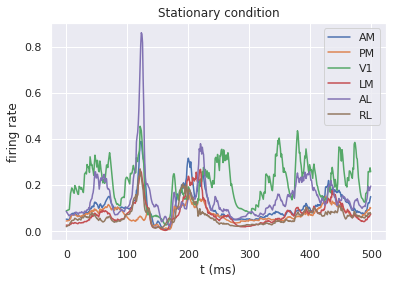

In [36]:
itrial = 0
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate_rcd_stationary[:,itrial, i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Stationary condition')

Text(0.5, 1.0, 'Running condition')

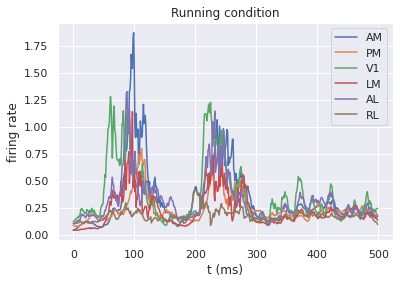

In [28]:
itrial = 0
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate_rcd_running[:,itrial, i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Running condition')

Text(0.5, 1.0, 'Experimental; Stationary condition')

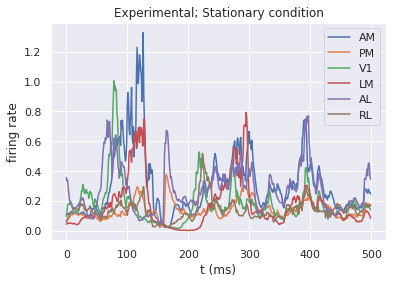

In [44]:
itrial = 0
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(stationary_model_list[i].log_lmbd[:,itrial]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Experimental; Stationary condition')

Text(0.5, 1.0, 'Experimental; Running condition')

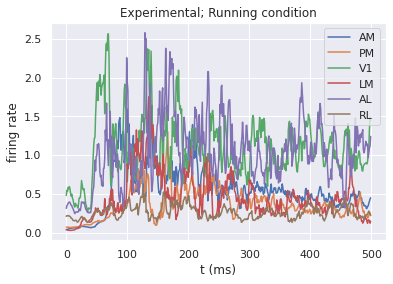

In [43]:
itrial = 0
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(running_model_list[i].log_lmbd[:,itrial]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Experimental; Running condition')

## Use Lambda^2 as a coefficient to simulate

In [32]:
# Fit
penalty = 3e-1
tau = 10
order = 2
num_basis_baseline = 30
max_iter = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}
ROI_filter = {}
statistics_filter = {}
ROI_output = {}
statistics_output = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j],apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory', target_probe, order=order, tau=tau,apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)


6it [03:34, 35.75s/it]


In [33]:
# Stationary model simulation
nepoch = 10
model_list = stationary_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd_stationary = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd_stationary = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
peaks_rcd_stationary = np.zeros((2, nepoch*model_list[0].ntrial, len(model_list)))

for iepoch in tqdm( range(nepoch) ):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction', 'refractory']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_params = np.zeros(nneuron)
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                    baseline_mat[:, ineuron] += model.results.params[67+itrial]
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

            refractory_params[ineuron] = model.results.params[66]
        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (recent_spike_sum/tau)**2
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory*refractory_params
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd_stationary[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd_stationary[:, iepoch*model_list[0].ntrial + itrial, :] = spikes
        for ineuron in range(nneuron):
            peaks_rcd_stationary[0, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[:150, ineuron])[:, np.newaxis], std=5))
            peaks_rcd_stationary[1, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[150:, ineuron])[:, np.newaxis], std=5))

100%|████████████████████████████████████| 10/10 [00:27<00:00,  2.79s/it]


In [34]:
# Running model simulation
nepoch = 10
model_list = running_model_list
tau = 10

import copy
import numpy.random
probe_list = V1.selected_probes
spikes_rcd_running = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
log_firing_rate_rcd_running = np.zeros((model_list[0].nt, nepoch*model_list[0].ntrial, len(model_list)))
peaks_rcd_running = np.zeros((2, nepoch*model_list[0].ntrial, len(model_list)))

for iepoch in tqdm( range(nepoch) ):
    for itrial in range(model_list[0].ntrial):
        
        nneuron = len(model_list)
        # Get three dimension matrix of coupling filters for better computing. 
        max_histories = 1
        max_histories_refractory = 1
        nt = model_list[0].nt
        # allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
        allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef', 'interaction', 'refractory']
        coupling_mat = np.zeros((max_histories, nneuron, nneuron))
        refractory_params = np.zeros(nneuron)
        baseline_mat = np.zeros((nt, nneuron))
        spikes = np.zeros((nt, nneuron, 1))
        probe2num = {}
        for iprobe, probe in enumerate(probe_list):
            probe2num[probe] = iprobe

        for ineuron in range(nneuron):
            assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), \
                "Only support inhomogeneous_baseline and coupling effects now!"
            model = model_list[ineuron]
            for ieffect, effect_type in enumerate(model.effect_type_list):

                if effect_type in ['inhomogeneous_baseline', ]:
                    baseline_mat[:, ineuron] = model.filters[ieffect]
                    baseline_mat[:, ineuron] = GLM.apply_warping_to_predictors(V1.time_line, 
                                                                               baseline_mat[:, ineuron][:,None], 
                                                                               model_list[0].shifts[itrial,:][None,:], 
                                                                               model_list[0].nt).squeeze()
                    baseline_mat[:, ineuron] += model.results.params[67+itrial]
                elif effect_type in ['coupling']:
                    nhistories = len(model.filters[ieffect])
                    probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
                    iprobe = probe2num[probe_name]
                    if nhistories > max_histories:
                        coupling_mat_old = coupling_mat
                        coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                        coupling_mat[-max_histories:, :, :] = coupling_mat_old
                        max_histories = nhistories

                    coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

            refractory_params[ineuron] = model.results.params[66]
        log_firing_rate = baseline_mat[:,:,np.newaxis]
        spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

        recent_spike_sum = copy.deepcopy(spikes[0, :, 0])

        for t in range(1, nt):
            recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
            nhistories = min(t, max_histories)
            temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
            refractory = (recent_spike_sum/tau)**2
            log_firing_rate[t,:,0] += temp_log_firing_rate + refractory*refractory_params
        #     log_firing_rate[t,:,0] = np.minimum(log_firing_rate[t,:,0], MAX_FIRING_RATE)
            spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
            recent_spike_sum += spikes[t, :, 0]

        log_firing_rate = log_firing_rate.squeeze()
        spikes = spikes.squeeze()
        
        log_firing_rate_rcd_running[:, iepoch*model_list[0].ntrial + itrial, :] = log_firing_rate
        spikes_rcd_running[:, iepoch*model_list[0].ntrial + itrial, :] = spikes
        for ineuron in range(nneuron):
            peaks_rcd_running[0, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[:150, ineuron])[:, np.newaxis], std=5))
            peaks_rcd_running[1, iepoch*model_list[0].ntrial + itrial, ineuron] = \
                np.nanargmax(utils.kernel_smoothing(np.exp(log_firing_rate[150:, ineuron])[:, np.newaxis], std=5))

100%|████████████████████████████████████| 10/10 [00:17<00:00,  1.75s/it]


### PSTH compare

#### Experimental PSTH

Text(0.5, 1.0, 'Experimental average firing rate across trials (resting condition)')

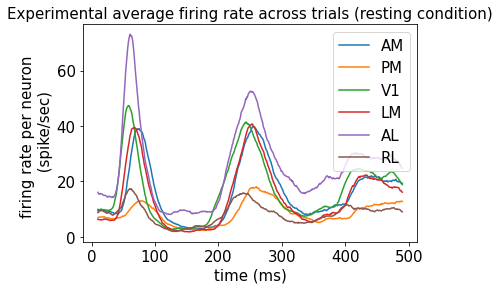

In [35]:
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']

fontsize = 15
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(stationary_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Experimental average firing rate across trials (resting condition)', fontsize=fontsize)

Text(0.5, 1.0, 'Experimental average firing rate across trials (running condition)')

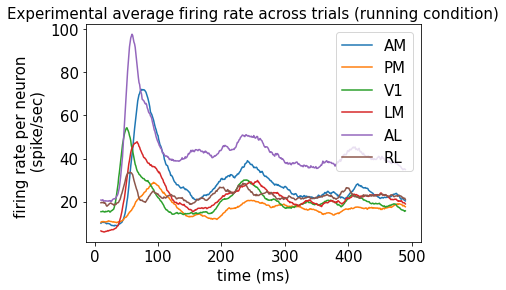

In [36]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(running_model_list[i].output.mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Experimental average firing rate across trials (running condition)', fontsize=fontsize)

#### Simulated PSTH

Text(0.5, 1.0, 'Simulated average firing rate across trials (resting condition)')

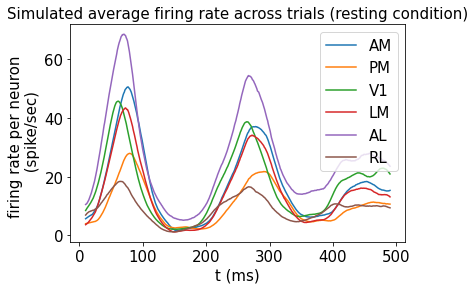

In [37]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd_stationary[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('t (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Simulated average firing rate across trials (resting condition)', fontsize=fontsize)

Text(0.5, 1.0, 'Simulated average firing rate across trials (running condition)')

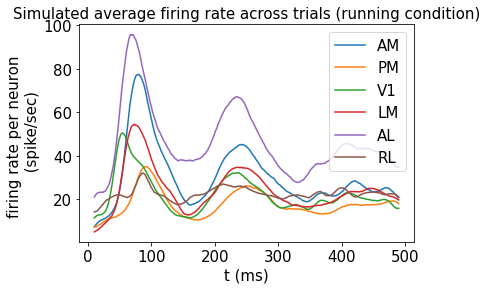

In [38]:
fig, ax = plt.subplots()
ax.tick_params(axis='both', which='major', labelsize=fontsize)
for i, probe_name in enumerate(name_list):
    plt.plot(1e3/mean_num_neuron[i]*utils.kernel_smoothing(spikes_rcd_running[:, :, i].mean(axis=1)[:, np.newaxis], std=10), label=probe_name)
plt.legend(fontsize=fontsize)
plt.xlabel('t (ms)', fontsize=fontsize)
plt.ylabel('firing rate per neuron \n (spike/sec)', fontsize=fontsize)
plt.title('Simulated average firing rate across trials (running condition)', fontsize=fontsize)

### Single trial plot

Text(0.5, 1.0, 'Stationary condition')

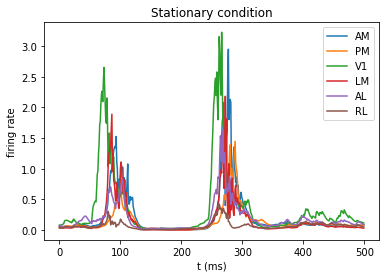

In [729]:
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate.squeeze()[:,i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Stationary condition')

Text(0.5, 1.0, 'Running condition')

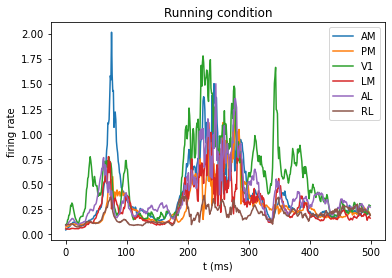

In [736]:
for i, probe_name in enumerate(name_list):
    plt.plot(np.exp(log_firing_rate.squeeze()[:,i]), label=probe_name)
plt.legend()
plt.xlabel('t (ms)')
plt.ylabel('firing rate')
plt.title('Running condition')

## Correlation and partial correlation

In [473]:
peaks_rcd = np.concatenate((peaks_rcd_stationary, peaks_rcd_running), axis=1)
peaks_rcd.shape

(2, 2100, 6)

In [474]:
GLM.corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.56112903, 0.63137318],
       [0.56112903, 1.        , 0.54067431],
       [0.63137318, 0.54067431, 1.        ]])

In [475]:
GLM.partial_corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.40691691, 0.53989767],
       [0.40691691, 1.        , 0.39778186],
       [0.53989767, 0.39778186, 1.        ]])

In [493]:
model_list = stationary_model_list
peaks_rcd_stationary = np.zeros((2, model_list[0].ntrial, len(model_list)))
for itrial in range(model_list[0].ntrial):
    for ineuron in range(len(model_list)):
        peaks_rcd_stationary[1, itrial, ineuron] = \
            np.nanargmax(utils.kernel_smoothing(np.exp(model_list[ineuron].log_lmbd[150:, itrial])[:, np.newaxis], std=1))

model_list = running_model_list
peaks_rcd_running = np.zeros((2, model_list[0].ntrial, len(model_list)))
for itrial in range(model_list[0].ntrial):
    for ineuron in range(len(model_list)):
        peaks_rcd_running[1, itrial, ineuron] = \
            np.nanargmax(utils.kernel_smoothing(np.exp(model_list[ineuron].log_lmbd[150:, itrial])[:, np.newaxis], std=1))
        

In [494]:
peaks_rcd = np.concatenate((peaks_rcd_stationary, peaks_rcd_running), axis=1)
peaks_rcd.shape

(2, 210, 6)

In [495]:
GLM.corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.32526144, 0.27682891],
       [0.32526144, 1.        , 0.41103366],
       [0.27682891, 0.41103366, 1.        ]])

In [496]:
GLM.partial_corr(peaks_rcd[1, :, 2:5])

array([[1.        , 0.3981565 , 0.29935124],
       [0.3981565 , 1.        , 0.50616431],
       [0.29935124, 0.50616431, 1.        ]])

In [806]:
running_model_list[0].effect_type_list

['inhomogeneous_baseline',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'coupling',
 'refractory']